In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import scipy.fft as sp

from src.sample import Z
from src.tests import run_tests
# from src.CRB import CRB
from src.MLE import MLE
# from src.FFT import estimate_frequency

from constants import SIGMA_R, T, N, Fs, omega_0, n0, P, Q, phi


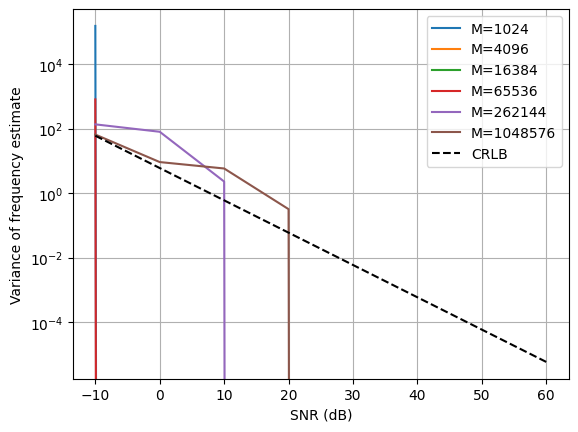

In [5]:
def CRB(sigma):
    
    var_omega_hat = 12*sigma ** 2 / (T**2 * N*(N**2 - 1))
    var_phi_hat   = 12 * sigma ** 2 * (N * n0**2 + 2 * n0 * P + Q) / (N**2 * (N**2 - 1)) 

    return var_omega_hat, var_phi_hat


def estimate_omega_phi_FFT(z,T, M):
    
    #Zero padding
    Y = sp.fft(z, n=M)

    #
    m_star = np.argmax(np.abs(Y))
    omega_hat = 2*np.pi*m_star / (M*T)

    #Estimsting anglefrequency
    F_hat = Y[m_star]
    phi_hat = np.angle(np.exp(-1j*omega_hat*n0*T)*F_hat)
    
    return omega_hat, phi_hat




def main():
    #run_tests() 
    #Get Z, which is the sampled values of X(t)'
    ##Iterations for different M and SNR
    Ms = np.array([2**10, 2**12, 2**14, 2**16, 2**18, 2**20])
    SNR_db = np.array([-10, 0, 10, 20, 30, 40, 50, 60])
    SNR_lin = 10 ** (SNR_db / 10)
    
    iter = 1000

    omega_vars = np.zeros((len(SNR_lin)))
   
    for M in Ms:
        omega_vars = np.zeros((len(SNR_lin)))
        phi_vars = np.zeros((len(SNR_lin)))

        crb_omega = np.zeros((len(SNR_lin)))
        crb_phi = np.zeros((len(SNR_lin)))
        
        for snr_index, SNR in enumerate(SNR_lin):
            sigma = np.sqrt(1/(2*SNR))
            e_omegas = np.zeros(iter)
            e_phis = np.zeros(iter)

            crb_omega[snr_index], crb_phi[snr_index] = CRB(sigma)


            for i in range(iter):

                z= Z(sigma) ##Generate new noicy signal
                z= np.asarray(z).flatten()

                omega_hat, phi_hat = estimate_omega_phi_FFT(z, T, M)    

                e_omegas[i] = omega_0 - omega_hat
                e_phis[i] = np.angle(np.exp(1j * (phi - phi_hat)))

            #Calculate variance 
            omega_vars[snr_index] = np.var(e_omegas) ##Variansen til omega er ofte mindre enn crlb det gir ikke mening
            phi_vars[snr_index] = np.var(e_phis)
            
        plt.semilogy(SNR_db, omega_vars, label=f"M={M}")
    sigma_last = np.sqrt(1 / (2 * SNR_lin))  # vectorisert
    crb_omega_plot = 12 * sigma_last**2 / (T**2 * N * (N**2 - 1))
    plt.semilogy(SNR_db, crb_omega_plot,'k--' ,label="CRLB")
    plt.xlabel("SNR (dB)")
    plt.ylabel("Variance of frequency estimate")
    plt.legend()
    plt.grid()


 
    return None

# if __name__ == "__main__":
#     main()
main()